In [1]:
import time
start_time = time.perf_counter()

# Prelims

In [2]:
import numpy as np
from environment import custom_four_rooms
from helpers import get_inverted_model
from inverse_prediction import get_trajectories, get_step_distributions
from visualisations import show_distribution, show_distribution_comparison
from analysis_functions import state_distribution_to_environment_distribution, get_kl_from_reference, get_tv_from_reference

In [3]:
env = custom_four_rooms(isWindy=True)
goals = [
    (1, 1),
    (1, 9),
    (9, 1),
    (9, 9),
    (5, 3),
]

In [4]:
n_agents = 5

In [5]:
goal_index = 3
goal_state = goals[goal_index]
n_steps = 50
n_trajectories = 100000

In [6]:
agents = []

for i in range(n_agents):
  print(f'Training and extracting agent {i}')
  agent_start_time = time.perf_counter()
  Q, P_hat, bellman_residual = get_inverted_model(env, goals, n_episodes=100000,
                                                  seed_train = i)
  agent = {'Q': Q, 'P_hat': P_hat, 'bellman_residual':bellman_residual}
  agents.append(agent)
  print(f'Running {n_trajectories} trajectories from agent {i} using its own world model')
  model_trajectories = get_trajectories(
      env,
      Q,
      goal_index=goal_index,
      goal_state=goal_state,
      n_trajectories=n_trajectories,
      n_steps=n_steps,
      source="model",
      P_hat=P_hat,
  )
  agents[i]['model_trajectories'] = model_trajectories
  agent_end_time = time.perf_counter()
  agent_execution_time = agent_end_time - agent_start_time
  print(f"Train and extraction time: {agent_execution_time:.4f} seconds")


Training and extracting agent 0
Running 100000 trajectories from agent 0 using its own world model
Train and extraction time: 120.1616 seconds
Training and extracting agent 1
Running 100000 trajectories from agent 1 using its own world model
Train and extraction time: 117.6252 seconds
Training and extracting agent 2
Running 100000 trajectories from agent 2 using its own world model
Train and extraction time: 118.7877 seconds
Training and extracting agent 3
Running 100000 trajectories from agent 3 using its own world model
Train and extraction time: 119.2295 seconds
Training and extracting agent 4
Running 100000 trajectories from agent 4 using its own world model
Train and extraction time: 118.6498 seconds


# Comparison functions

In [7]:
def get_comparison_matrix(env, agents):
  n_agents = len(agents)
  comparison_matrix_kl = np.zeros((n_agents, n_agents))
  comparison_matrix_tv = np.zeros((n_agents, n_agents))
  for i in range (n_agents):
    print(f'Using world model from Agent {i}')
    agent_start_time = time.perf_counter()
    P_hat_i = agents[i]['P_hat']
    for j in range(n_agents):
      #Note if we dont want to do the full comparison with ourselves
      #we can skip it here
      #if i == j:
        #continue
      Q_j = agents[j]['Q']
      reference_distributions = get_step_distributions( agents[j]['model_trajectories'])
      print(f'Getting distributions for Agent {j} using world model from Agent {i}')
      comparison_trajectories = get_trajectories(
          env,
          Q_j,
          goal_index=goal_index,
          goal_state=goal_state,
          n_trajectories=n_trajectories,
          n_steps=n_steps,
          source="model",
          P_hat=P_hat_i,
        )
      comparison_distributions = get_step_distributions(comparison_trajectories)
      print(f'Getting KL and TV for Agent {i} and Agent {j}')
      comparison_matrix_kl[i, j] = np.mean(get_kl_from_reference(env, reference_distributions, comparison_distributions))
      comparison_matrix_tv[i, j] = np.mean(get_tv_from_reference(env, reference_distributions, comparison_distributions))


    agent_end_time = time.perf_counter()
    agent_execution_time = agent_end_time - agent_start_time
    print(f"Comparison time: {agent_execution_time:.4f} seconds")
  return comparison_matrix_kl, comparison_matrix_tv

In [8]:
comparison_matrix_kl, comparison_matrix_tv = get_comparison_matrix(env, agents)

Using world model from Agent 0
Getting distributions for Agent 0 using world model from Agent 0
Getting KL and TV for Agent 0 and Agent 0
Getting distributions for Agent 1 using world model from Agent 0
Getting KL and TV for Agent 0 and Agent 1
Getting distributions for Agent 2 using world model from Agent 0
Getting KL and TV for Agent 0 and Agent 2
Getting distributions for Agent 3 using world model from Agent 0
Getting KL and TV for Agent 0 and Agent 3
Getting distributions for Agent 4 using world model from Agent 0
Getting KL and TV for Agent 0 and Agent 4
Comparison time: 217.5759 seconds
Using world model from Agent 1
Getting distributions for Agent 0 using world model from Agent 1
Getting KL and TV for Agent 1 and Agent 0
Getting distributions for Agent 1 using world model from Agent 1
Getting KL and TV for Agent 1 and Agent 1
Getting distributions for Agent 2 using world model from Agent 1
Getting KL and TV for Agent 1 and Agent 2
Getting distributions for Agent 3 using world mo

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def visualise_comparison_matrix(comparison_matrix, title):
  model_labels = [f"Model {i}" for i in range(len(agents))]
  policy_labels = [f"Policy {i}" for i in range(len(agents))]
  df = pd.DataFrame(comparison_matrix, index=model_labels, columns=policy_labels)

  plt.figure(figsize=(10, 8))
  sns.heatmap(df, annot=True, fmt=".3f", cmap="viridis")
  plt.title(title)
  plt.show()

In [10]:
def rank_models(comparison_matrix_kl, comparison_matrix_tv, sort_by='kl'): #sortby = kl, tv
  model_labels = [f"Model {i}" for i in range(len(agents))]
  model_scores = pd.DataFrame({
      "mean cross-policy KL": [np.mean(np.delete(comparison_matrix_kl[i],i)) for i in range(len(agents))],
      "mean cross-policy TV": [np.mean(np.delete(comparison_matrix_tv[i],i)) for i in range(len(agents))]},
                              index=model_labels)
  if sort_by == 'kl':
    display(model_scores.sort_values("mean cross-policy KL").style.background_gradient(cmap="viridis_r").format("{:.3f}"))
  elif sort_by == 'tv':
    display(model_scores.sort_values("mean cross-policy TV").style.background_gradient(cmap="viridis_r").format("{:.3f}"))


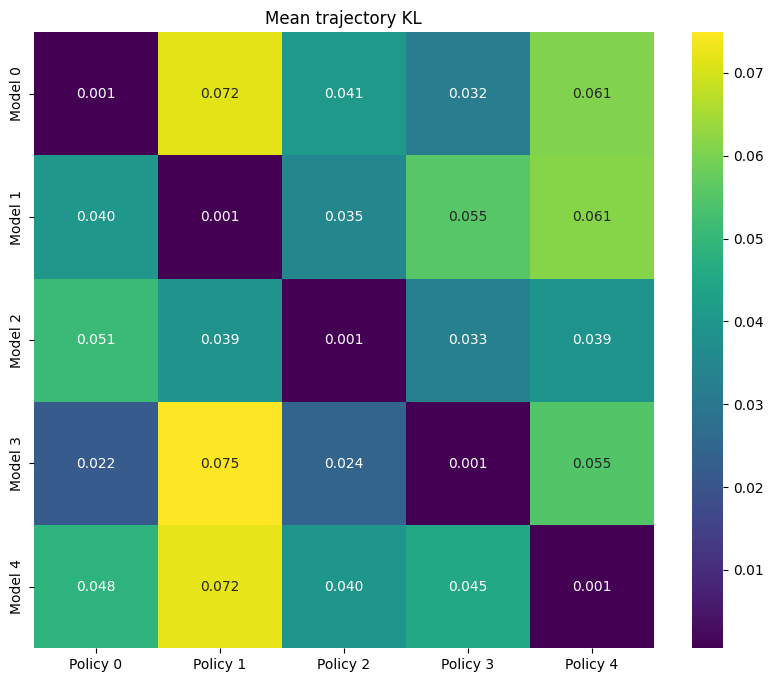

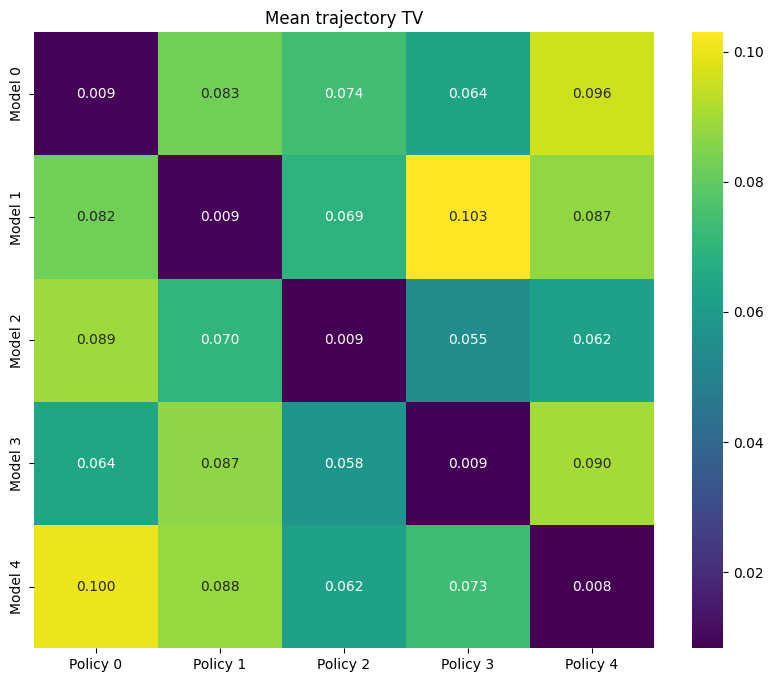

,mean cross-policy KL,mean cross-policy TV
Model 2,0.040,0.069
Model 3,0.044,0.075
Model 1,0.048,0.086
Model 0,0.051,0.079
Model 4,0.051,0.081


In [11]:
visualise_comparison_matrix(comparison_matrix_kl, "Mean trajectory KL")
visualise_comparison_matrix(comparison_matrix_tv, "Mean trajectory TV")
rank_models(comparison_matrix_kl, comparison_matrix_tv)

In [14]:
end_time = time.perf_counter()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")


Execution time: 1681.5671 seconds
